In [28]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Bhukya Rajnath\OneDrive\Desktop\E-commeraces sales data\archive\Amazon Sale Report.csv",
                low_memory=False
                
)
df

#What is low_memory=False?
#Normally Pandas reads the files in chunks to save memory
#It tells pands to read the entire file first ,then decide data type 

In [3]:
df.shape

(128975, 24)

In [4]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [6]:
print(df.columns[23])

Unnamed: 22


In [7]:
df["Unnamed: 22"].value_counts(dropna=False)

Unnamed: 22
False    79925
NaN      49050
Name: count, dtype: int64

In [8]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

**Understand Data Type**
- Data should be DateTime,not text
- now change object --> to datetime64


In [9]:
df.drop("Unnamed: 22",axis=1,inplace=True)
df

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,128970,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,...,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN
128971,128971,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,...,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
128972,128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,...,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN
128973,128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,...,1,INR,1199.00,Halol,Gujarat,389350.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN


In [22]:
df["Date"]=pd.to_datetime(df["Date"])
df

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Month,Year,Day
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,4,2022,Saturday
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,4,2022,Saturday
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,4,2022,Saturday
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,4,2022,Saturday
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,4,2022,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,128970,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,...,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN,5,2022,Tuesday
128971,128971,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,...,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,5,2022,Tuesday
128972,128972,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,...,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN,5,2022,Tuesday
128973,128973,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,...,Halol,Gujarat,389350.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,5,2022,Tuesday


In [11]:
print(df["Date"].dtype)

datetime64[ns]


**Extract Month**

In [12]:
df['Month']=df["Date"].dt.month

**Extraxt Year**

In [13]:
df["Year"]=df["Date"].dt.year

**Day Name**

In [14]:
df["Day"]=df["Date"].dt.day_name()

- This helps answer business questions like:
   - Which day generates the most sales?

**DATA CLEANING**

In [15]:
# Missing Values

df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Month                     0
Year                      0
Day                       0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['Amount'].describe()

count    121180.000000
mean        648.561465
std         281.211687
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64

In [18]:
df[df["Amount"].isnull()][["Status","Amount"]].head(20)

,Status,Amount
8,Cancelled,NaN
29,Cancelled,NaN
65,Cancelled,NaN
84,Cancelled,NaN
95,Cancelled,NaN
101,Cancelled,NaN
132,Cancelled,NaN
139,Cancelled,NaN
155,Cancelled,NaN
165,Cancelled,NaN


- We want to know:
  - Are these cancelled orders?
  - Returned Orders?
  - Pending Orders
- If most are cancelled orders we may keep them for orders analysis but exculed
  - them form revenye analysis

- Promotion IDs
 #49153 
- No promotion was used 
- Not  data qulity issue

- Fullfilled By
#89698
- huge missing count
- Before dropping ,Inspect it:

In [19]:
df['fulfilled-by'].value_counts(dropna=False)

fulfilled-by
NaN          89698
Easy Ship    39277
Name: count, dtype: int64

**Duplicate Analysis**

In [20]:
df.duplicated().sum()

np.int64(0)

**Amount Analysis**

- Mean = 648.56(Average order value is 649rs)
- minimum =0(A sale amount of 0rs is suspicious)
- Maximun = 5584 (Highest order value 5,584rs)

In [21]:
df[df["Amount"]==0][["Status","Amount"]].head(20)

,Status,Amount
212,Shipped - Delivered to Buyer,0.0
374,Shipped - Returned to Seller,0.0
385,Shipped,0.0
388,Shipped - Delivered to Buyer,0.0
392,Shipped,0.0
436,Shipped,0.0
441,Shipped - Delivered to Buyer,0.0
446,Shipped,0.0
449,Shipped,0.0
729,Shipped - Delivered to Buyer,0.0


**Lets Understand the business**

In [23]:
#Top order Status
df["Status"].value_counts()

Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [24]:
#Product categories
df["Category"].value_counts()

Category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

In [25]:
#Fullfillment type
df["Fulfilment"].value_counts()

Fulfilment
Amazon      89698
Merchant    39277
Name: count, dtype: int64

In [27]:
#revenue by category
df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

Category
Set              39204124.03
kurta            21299546.70
Western Dress    11216072.69
Top               5347792.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64

**1.Order Status Analysis**
- Business Insights
    - Cancel orders(18332/128975*100 = 14.2% cancelled ratio)

**2.Fulfilment Analysis**
- Business insight

  - Amazon handles most orders(89698/128975*100 = 69.5%,
                                            merchant=30.5%)
- insight
    - Nearly 70% of order were fulfilled by Amazon,indicating a strong 
      - Reliance on Amazon's Logistics network

**3.Revenue by Category**

- set has highest revenue category>>kurtha>>western dress

**Visualizations**

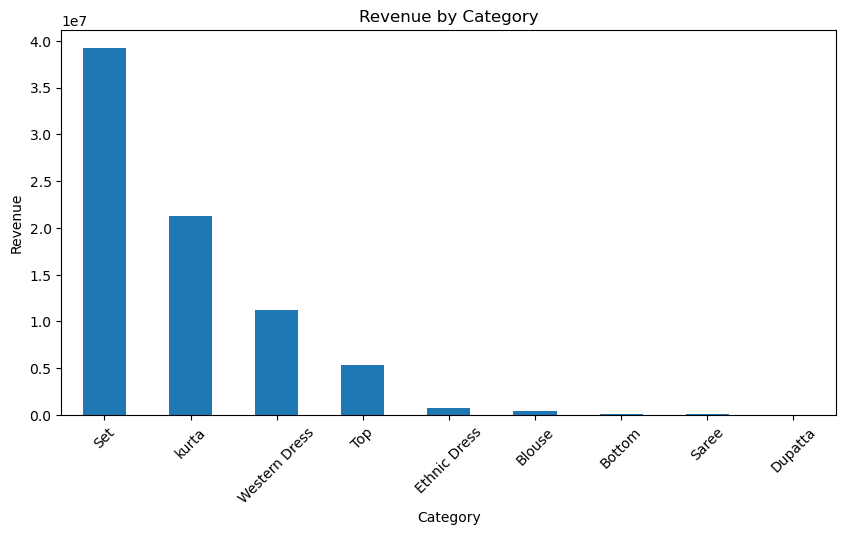

In [29]:
# Revenue by category Chart

category_sales = (
    df.groupby("Category")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
category_sales.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**Top 10 States by Revenue**

In [30]:
df.groupby("ship-state")["Amount"] \
  .sum()\
  .sort_values(ascending=False)\
  .head(10)

ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4235215.97
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64

**Top 10 Cities By Revenue**

In [31]:
df.groupby("ship-city")["Amount"]\
  .sum()\
  .sort_values(ascending=False)\
  .head(10)

ship-city
BENGALURU    6849664.99
HYDERABAD    4946032.82
MUMBAI       3704461.80
NEW DELHI    3613874.78
CHENNAI      3098745.74
PUNE         2338518.18
KOLKATA      1414978.87
GURUGRAM     1221618.74
THANE        1004355.29
LUCKNOW       933926.34
Name: Amount, dtype: float64

**Monthly Revenue trend**

In [32]:
df.groupby("Month")["Amount"]\
  .sum()\
  .sort_values()

Month
3      101683.85
6    23425809.38
5    26226476.75
4    28838708.32
Name: Amount, dtype: float64

In [33]:
df[["Date","Month","Year","Day"]].head()

,Date,Month,Year,Day
0,2022-04-30,4,2022,Saturday
1,2022-04-30,4,2022,Saturday
2,2022-04-30,4,2022,Saturday
3,2022-04-30,4,2022,Saturday
4,2022-04-30,4,2022,Saturday


In [34]:
df.groupby('Month').size()

Month
3      171
4    49067
5    42040
6    37697
dtype: int64

In [35]:
df["Amount"].sum()

np.float64(78592678.3)

In [36]:
#Quality
df.groupby("Category")["Qty"]\
  .sum()\
  .sort_values(ascending=False)

Category
Set              45289
kurta            45045
Western Dress    13943
Top               9903
Ethnic Dress      1053
Blouse             863
Bottom             398
Saree              152
Dupatta              3
Name: Qty, dtype: int64

In [37]:
df.groupby("ship-state")["Order ID"].count().sort_values(ascending=False).head(10)

ship-state
MAHARASHTRA       22260
KARNATAKA         17326
TAMIL NADU        11483
TELANGANA         11330
UTTAR PRADESH     10638
DELHI              6782
KERALA             6585
WEST BENGAL        5963
ANDHRA PRADESH     5430
Gujarat            4489
Name: Order ID, dtype: int64

**Average Order Value Per Category**

In [38]:
category_analysis = (
    df.groupby("Category")
      .agg({
          "Amount":"sum",
          "Qty":"sum"
      })
)

category_analysis["Avg_Price"] = (
    category_analysis["Amount"] /
    category_analysis["Qty"]
)

category_analysis.sort_values(
    by="Amount",
    ascending=False
)

,Amount,Qty,Avg_Price
Category,,,
Set,39204124.03,45289,865.643402
kurta,21299546.70,45045,472.850410
Western Dress,11216072.69,13943,804.423201
Top,5347792.30,9903,540.017399
Ethnic Dress,791217.66,1053,751.393789
Blouse,458408.18,863,531.179815
Bottom,150667.98,398,378.562764
Saree,123933.76,152,815.353684
Dupatta,915.00,3,305.000000


**Revenue Percentage** 

In [39]:
category_sales=(
    df.groupby("Category")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

(category_sales/category_sales.sum())*100

Category
Set              49.882667
kurta            27.101184
Western Dress    14.271142
Top               6.804441
Ethnic Dress      1.006732
Blouse            0.583271
Bottom            0.191707
Saree             0.157691
Dupatta           0.001164
Name: Amount, dtype: float64

**Top State Visualization**

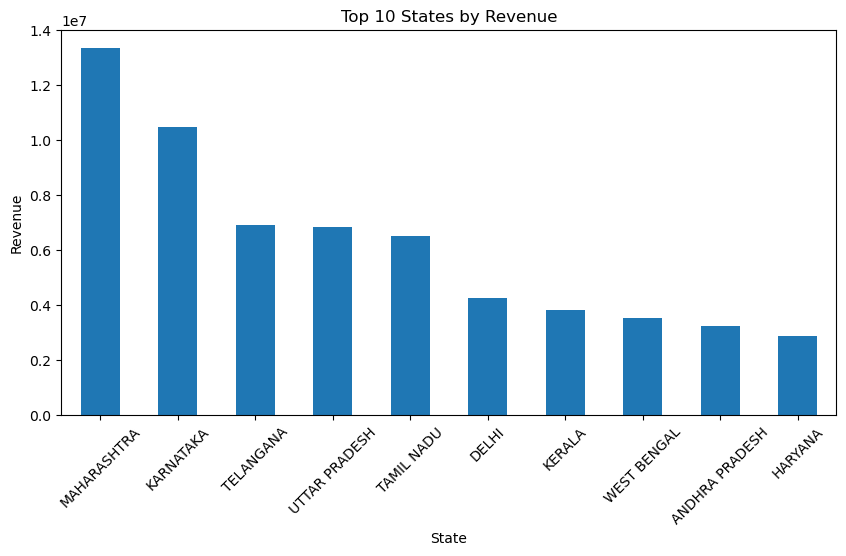

In [40]:
import matplotlib.pyplot as plt

top_states = (
    df.groupby("ship-state")["Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar")

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()